In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

# Local imports
from cnn import SimpleCNN
from data.load_cifar import CIFAR10
from train import train_model

# Device selection (prep for potential GPU usage in e.g Colab)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cpu


In [5]:
# Create datasets
train_dataset = CIFAR10(split="train")
test_dataset  = CIFAR10(split="test")

# Create dataloaders
trainloader = DataLoader(
    train_dataset,
    batch_size=128,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valloader = DataLoader(
    test_dataset,
    batch_size=256,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))


/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/data/load_cifar.py:24: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  dict = pickle.load(fo, encoding="bytes")


Train samples: 50000
Test samples: 10000


In [6]:
# check the "batching"
images, labels = next(iter(trainloader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels.dtype)


/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Image batch shape: torch.Size([128, 3, 32, 32])
Label batch shape: torch.Size([128])
Image dtype: torch.float32
Label dtype: torch.int64


In [7]:
model = SimpleCNN(
    in_channels=3,
    num_classes=10,
    input_size=32,
    base_channels=32,
    channel_multiplier=2
)

model = model.to(device)
print(model)


SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Linear(in_features=2048, out_features=256, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.5, inplace=False)
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)


In [8]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3
)


In [9]:
trained_model = train_model(
    model=model,
    trainloader=trainloader,
    valloader=valloader,
    optimizer=optimizer,
    criterion=criterion,
    device=device,
    epochs=10
)


Epoch 1/10


Training:   0%|          | 0/391 [00:00<?, ?it/s]/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Train Loss: 1.6656 | Train Acc: 0.3835
Val   Loss: 1.3414 | Val   Acc: 0.5132

Epoch 2/10


Train Loss: 1.3101 | Train Acc: 0.5284
Val   Loss: 1.1309 | Val   Acc: 0.5947

Epoch 3/10


Train Loss: 1.1384 | Train Acc: 0.5966
Val   Loss: 1.0154 | Val   Acc: 0.6404

Epoch 4/10


...

Train Loss: 0.8451 | Train Acc: 0.7034
Val   Loss: 0.8260 | Val   Acc: 0.7106

Epoch 7/10


Train Loss: 0.7886 | Train Acc: 0.7244
Val   Loss: 0.8419 | Val   Acc: 0.7115

Epoch 8/10


Train Loss: 0.7405 | Train Acc: 0.7413
Val   Loss: 0.7649 | Val   Acc: 0.7364

Epoch 9/10


Train Loss: 0.7014 | Train Acc: 0.7555
Val   Loss: 0.7512 | Val   Acc: 0.7400

Epoch 10/10


Train Loss: 0.6570 | Train Acc: 0.7713
Val   Loss: 0.7480 | Val   Acc: 0.7439


In [ ]:
# save the trained model
file_name = "simple_cnn_cifar10_v1.pth"
torch.save(trained_model.state_dict(), file_name)
#del trained_model

In [22]:
# load the saved model with the same parameters initially set
trained_model = SimpleCNN(in_channels=3, num_classes=10, input_size=32, base_channels=32, channel_multiplier=2)
trained_model.load_state_dict(torch.load(file_name))

<All keys matched successfully>

In [23]:
trained_model.eval()

correct = 0
total = 0

with torch.no_grad():
    for images, labels in valloader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = trained_model(images)
        _, preds = outputs.max(1)

        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

print(f"Final validation accuracy: {correct / total:.4f}")


/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Final validation accuracy: 0.7439


In [31]:
from analysis.evaluation import evaluate_model

/Users/reiterer/Library/CloudStorage/OneDrive-Persönlich/TU Wien/MSc Data Science/WS25/MachineLearning/Exercise3/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)



Model Evaluation
----------------
Overall accuracy: 0.7439

Per-class accuracy:
  airplane: 0.791
automobile: 0.863
      bird: 0.605
       cat: 0.591
      deer: 0.620
       dog: 0.660
      frog: 0.801
     horse: 0.829
      ship: 0.840
     truck: 0.839

Classification report:
              precision    recall  f1-score   support

    airplane      0.804     0.791     0.797      1000
  automobile      0.866     0.863     0.864      1000
        bird      0.713     0.605     0.655      1000
         cat      0.529     0.591     0.558      1000
        deer      0.741     0.620     0.675      1000
         dog      0.605     0.660     0.631      1000
        frog      0.817     0.801     0.809      1000
       horse      0.720     0.829     0.770      1000
        ship      0.875     0.840     0.857      1000
       truck      0.812     0.839     0.825      1000

    accuracy                          0.744     10000
   macro avg      0.748     0.744     0.744     10000
weighted av

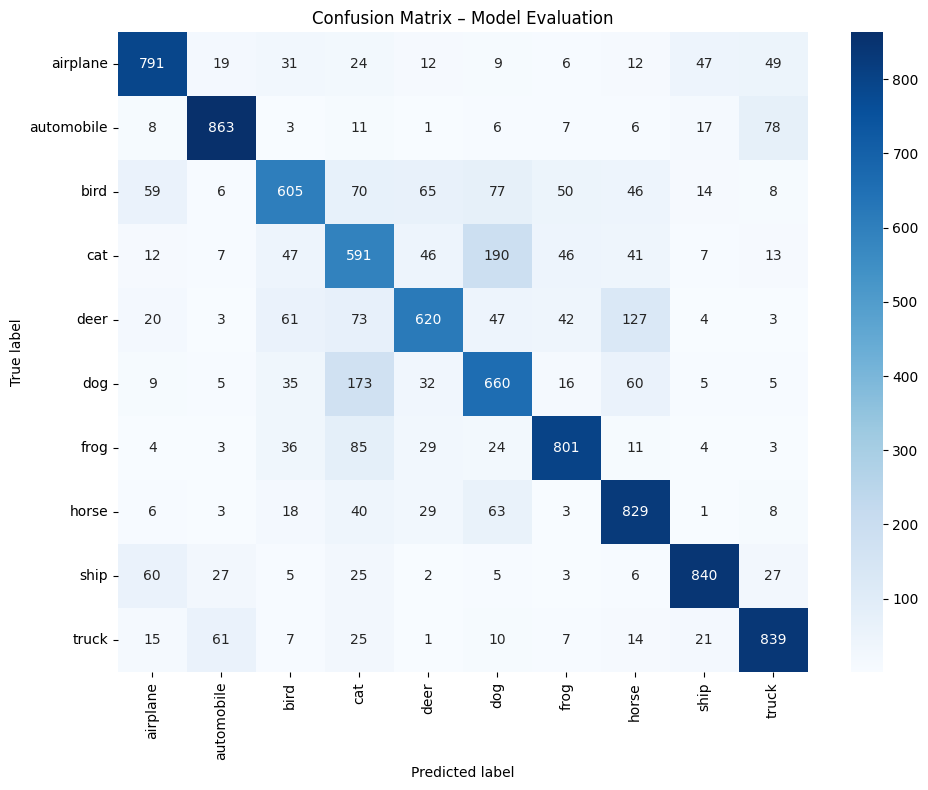

{'overall_accuracy': 0.7439000010490417,
 'per_class_accuracy': array([0.791, 0.863, 0.605, 0.591, 0.62 , 0.66 , 0.801, 0.829, 0.84 ,
        0.839]),
 'confusion_matrix': array([[791,  19,  31,  24,  12,   9,   6,  12,  47,  49],
        [  8, 863,   3,  11,   1,   6,   7,   6,  17,  78],
        [ 59,   6, 605,  70,  65,  77,  50,  46,  14,   8],
        [ 12,   7,  47, 591,  46, 190,  46,  41,   7,  13],
        [ 20,   3,  61,  73, 620,  47,  42, 127,   4,   3],
        [  9,   5,  35, 173,  32, 660,  16,  60,   5,   5],
        [  4,   3,  36,  85,  29,  24, 801,  11,   4,   3],
        [  6,   3,  18,  40,  29,  63,   3, 829,   1,   8],
        [ 60,  27,   5,  25,   2,   5,   3,   6, 840,  27],
        [ 15,  61,   7,  25,   1,  10,   7,  14,  21, 839]]),
 'predictions': tensor([5, 8, 8,  ..., 5, 4, 7]),
 'labels': tensor([3, 8, 8,  ..., 5, 1, 7])}

In [32]:
class_names = ["airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck" ]
evaluate_model(trained_model, valloader, device="cpu", class_names=class_names)